## Imports

In [4]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import tqdm

## Device

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## Loading Preprocessed Dataset

In [7]:
df = pd.read_csv(
    r"C:\Users\HP\Documents\Major_Final\Github-code\Module-2_Mini-2\Data\Tweets.csv"
)

texts = df["text"].astype(str).tolist()
labels = df["target"].astype(int).tolist()

## Splitting Dataset

In [8]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

## Tokenizer

In [9]:
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

## Dataset Class

In [10]:
class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding=True,
            max_length=max_len
        )
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

## DataLoaders

In [11]:
train_dataset = TweetDataset(train_texts, train_labels, tokenizer)
val_dataset = TweetDataset(val_texts, val_labels, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

## MODEL — RoBERTa BASE

In [12]:
model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2
)
model.to(device)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
         

## CLASS WEIGHTS

In [13]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)

## Optimizer + Scheduler

In [14]:
optimizer = AdamW(model.parameters(), lr=2e-5)

total_steps = len(train_loader) * 4
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

## Training Loop

In [15]:
epochs = 5
best_val_loss = float("inf")

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)

        loss = loss_fn(outputs.logits, batch["labels"])
        loss.backward()

        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        total_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1)
        correct += (preds == batch["labels"]).sum().item()
        total += batch["labels"].size(0)

    train_losses.append(total_loss / len(train_loader))
    train_accs.append(correct / total)

    # Validation
    model.eval()
    val_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            loss = loss_fn(outputs.logits, batch["labels"])

            val_loss += loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            correct += (preds == batch["labels"]).sum().item()
            total += batch["labels"].size(0)

    val_losses.append(val_loss / len(val_loader))
    val_accs.append(correct / total)

    print(
        f"Epoch {epoch+1} | "
        f"Train Loss: {train_losses[-1]:.4f} | "
        f"Val Loss: {val_losses[-1]:.4f} | "
        f"Train Acc: {train_accs[-1]:.4f} | "
        f"Val Acc: {val_accs[-1]:.4f}"
    )

100%|█████████████████████████████████████████████████████████████████| 2270/2270 [00:00<00:00, 635415.78it/s]


Epoch 1/5: 100%|█████████████████████████████████████████████████████████████████| 2270/2270 [6:10:12<00:00,  9.82s/it]
Epoch 1 | Train Loss: 0.3617 | Val Loss: 0.3928 | Train Acc: 0.7923 | Val Acc: 0.7814


100%|████████████████████████████████████████████████████████████████| 2270/2270 [00:00<00:00, 1134811.69it/s]


Epoch 2/5: 100%|█████████████████████████████████████████████████████████████████| 2270/2270 [5:52:41<00:00,  9.30s/it]
Epoch 2 | Train Loss: 0.3194 | Val Loss: 0.3365 | Train Acc: 0.8416 | Val Acc: 0.8268


100%|████████████████████████████████████████████████████████████████| 2270/2270 [00:00<00:00, 1134541.24it/s]


Epoch 3/5: 100%|█████████████████████████████████████████████████████████████████| 2270/2270 [5:48:55<00:00,  9.24s/it]
Epoch 3 | Train Loss: 0.2418 | Val Loss: 0.2712 | Train Acc: 0.8829 | Val Acc: 0.8612


100%|█████████████████████████████████████████████████████████████████| 2270/2270 [00:00<00:00, 662981.00it/s]


Epoch 4/5: 100%|█████████████████████████████████████████████████████████████████| 2270/2270 [6:02:10<00:00,  9.56s/it]
Epoch 4 | Train Loss: 0.1726 | Val Loss: 0.1897 | Train Acc: 0.9024 | Val Acc: 0.8685


100%|█████████████████████████████████████████████████████████████████| 2270/2270 [00:00<00:00, 897452.17it/s]

Epoch 5/5: 100%|█████████████████████████████████████████████████████████████████| 2270/2270 [6:08:37<00:00,  9.75s/it]
Epoch 5 | Train Loss: 0.1493 | Val Loss: 0.1664 | Train Acc: 0.9141 | Val Acc: 0.8700


## SAVE MODEL

In [16]:
torch.save(model.state_dict(), "roberta-base-fine-tuned.pth")
print("Model saved successfully")

Model saved successfully


## Plots

In [17]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for batch in val_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        preds = torch.argmax(outputs.logits, dim=1)

        y_pred.extend(preds.cpu().numpy())
        y_true.extend(batch["labels"].cpu().numpy())

## Confusion Matrix

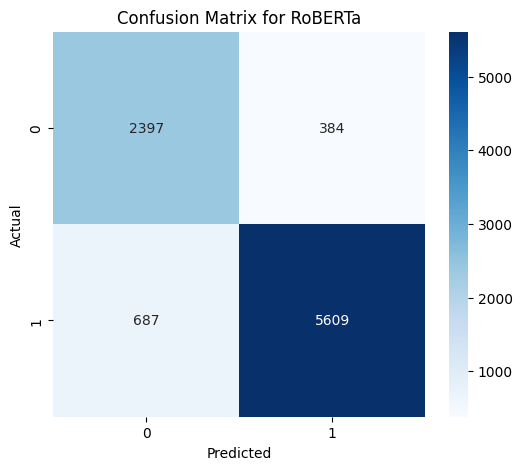

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Disaster", "Disaster"],
    yticklabels=["Non-Disaster", "Disaster"]
)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix for RoBERTa")
plt.tight_layout()
plt.show()

## Metrics

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Value": [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, average="weighted"),
        recall_score(y_true, y_pred, average="weighted"),
        f1_score(y_true, y_pred, average="weighted")
    ]
})

print(metrics_df)

      Metric  Value
0   Accuracy  0.870
1  Precision  0.877
2     Recall  0.872
3   F1-Score  0.873


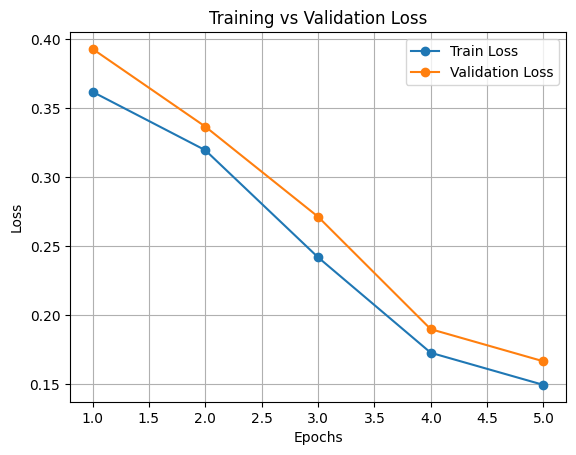

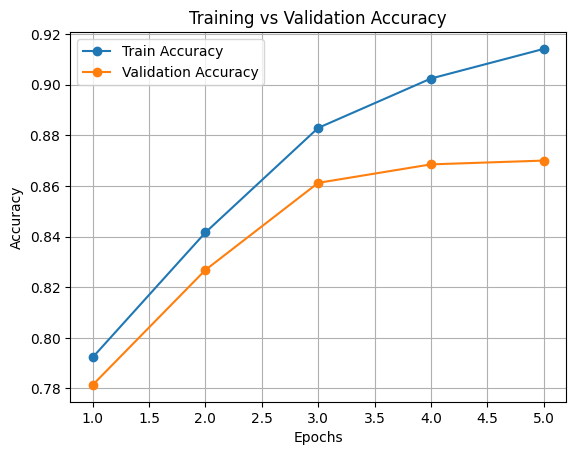

In [20]:
import matplotlib.pyplot as plt

# -------- Loss Curve --------
plt.figure()
plt.plot(epochs, train_loss,marker='o', label="Training Loss")
plt.plot(epochs, val_loss,marker='x', label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# -------- Accuracy Curve --------
plt.figure()
plt.plot(epochs, train_acc,marker='o', label="Training Accuracy")
plt.plot(epochs, val_acc,marker='x', label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


## Predictions

In [21]:
sample_df = pd.DataFrame({
    "Tweet": val_texts[:10],
    "Actual_Label": val_labels[:10],
    "Predicted_Label": y_pred[:10]
})

# Convert labels to readable form
sample_df["Actual_Label"] = sample_df["Actual_Label"].map({0: "Non-Disaster", 1: "Disaster"})
sample_df["Predicted_Label"] = sample_df["Predicted_Label"].map({0: "Non-Disaster", 1: "Disaster"})

sample_df

,Tweet,Actual_Label,Predicted_Label
0,Recovery Assistance Center at SW Weld Complex ...,Non-Disaster,Non-Disaster
1,"Llamas, dogs, horses, and owls are joining hum...",Disaster,Disaster
2,Tell me why or why not to adopt in this way ma...,Non-Disaster,Non-Disaster
3,I read an article about a woman who left (and ...,Disaster,Disaster
4,"I went up to moms today, 15 min car ride and t...",Disaster,Disaster
5,What's the best food spot in Bedford starving ...,Disaster,Non-Disaster
6,Junk food and movies in bed sounds pretty grea...,Disaster,Disaster
7,"Housing, food, water priorities in Bahamas aft...",Disaster,Disaster
8,Florida man parks Smart car in kitchen so it w...,Disaster,Disaster
9,Hurricane Matthew: Family rescued from car roo...,Disaster,Disaster
